In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import muon as mu
import scanpy as sc
import scirpy as ir
np.random.seed(42)
import random
random.seed(42)

import sys
sys.path.append("/ihome/ylee/yiz133/Code/Data processing/functions")
import importlib
import mdata_utils

2025-11-03 14:08:17.714861: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-03 14:08:17.715205: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-03 14:08:17.767832: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-03 14:08:39.880686: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# when functions changed
importlib.reload(mdata_utils)

<module 'mdata_utils' from '/ihome/ylee/yiz133/Code/Data processing/functions/mdata_utils.py'>

# GEX

In [3]:
data_path = "/ix1/ylee/Yifan_Zhang/Code_data/external/GSE182747 CNS young and old"
mdata = mu.read(data_path + "/GSE182747_CNS_young_old.h5mu")
mdata

MuData object with n_obs × n_vars = 37189 × 32285
  2 modalities
    gex:	37189 x 32285
      obs:	'sample', 'tissue'
    airr:	37189 x 0
      obs:	'sample'
      obsm:	'airr'

In [6]:
%cd $data_path

/ix1/ylee/Yifan_Zhang/Code_data/external/GSE182747 CNS young and old


In [7]:
mdata.obs['GSE'] = 'GSE182747'
mdata.obs['GSM'] = mdata['gex'].obs['sample']
mdata.obs['tissue'] = mdata['gex'].obs['tissue']

In [8]:
## data specific features
mdata.obs['condition'] = 'EAE'
mdata['gex'].obs['sample_id'] = mdata['gex'].obs['sample']

# mdata['gex'].obs['cell_type'] = 'CD4'
# mdata['gex'].obs['state'] = 'Trm'
    

In [9]:
mdata = mdata_utils.pp_EAE(mdata, celltype_score = 0.4, cellstate_score = 0.4, topN_variable = None)

In [10]:
print(mdata['gex'].obs['cell_type'].value_counts())
print(mdata['gex'].obs['state'].value_counts())

cell_type
CD8     11901
CD4     10034
Treg     4511
Th17      730
Name: count, dtype: int64
state
Exhaust       4596
Mem_Naive     2745
Activation    2698
IFN_stim      1988
Name: count, dtype: int64


# TCR

In [11]:
# mdata = mdata_ori.copy()
mdata['airr'].obs['sample_id'] = mdata.obs['sample_id']

ir.pp.index_chains(mdata)
ir.tl.chain_qc(mdata)

ir.pp.ir_dist(mdata)
ir.tl.define_clonotypes(mdata, receptor_arms="all", dual_ir="primary_only", within_group = 'sample_id')

meta_airr = ir.get.airr(mdata['airr'], ["cdr3_aa", "v_call", "j_call"] ,  ('VJ_1', 'VDJ_1'))

df2_filtered = meta_airr.loc[:, ~meta_airr.columns.isin(mdata.obs.columns)]
mdata.obs = mdata.obs.join(df2_filtered)
mdata.update()

# mdata.obs = mdata.obs.reindex(mdata.mod['gex'].obs.index)
ir.tl.clonal_expansion(mdata)


In [12]:
mdata

MuData object with n_obs × n_vars = 37189 × 13332
  obs:	'GSE', 'GSM', 'tissue', 'condition', 'state', 'cell_type', 'sample_id', 'VJ_1_cdr3_aa', 'VJ_1_v_call', 'VJ_1_j_call', 'VDJ_1_cdr3_aa', 'VDJ_1_v_call', 'VDJ_1_j_call'
  2 modalities
    gex:	37164 x 13332
      obs:	'sample', 'tissue', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'CD4score', 'CD8score', 'Tregscore', 'Th17score', 'cell_type', 'IFN_stimscore', 'Activationscore', 'Exhaustscore', 'Mem_Naivescore', 'state'
      var:	'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
      uns:	'log1p'
    airr:	37189 x 0
      obs:	'sample', 'sample_id', 'receptor_type', 'receptor_subtype', 'chain_pairing', 'clone_id', 'clone_id_size', 'clonal_expansion'
      uns:	'chain_indices', 'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'

In [13]:
count = (mdata['airr'].obs['clone_id_size'] == 1).sum()
print(count)

10972


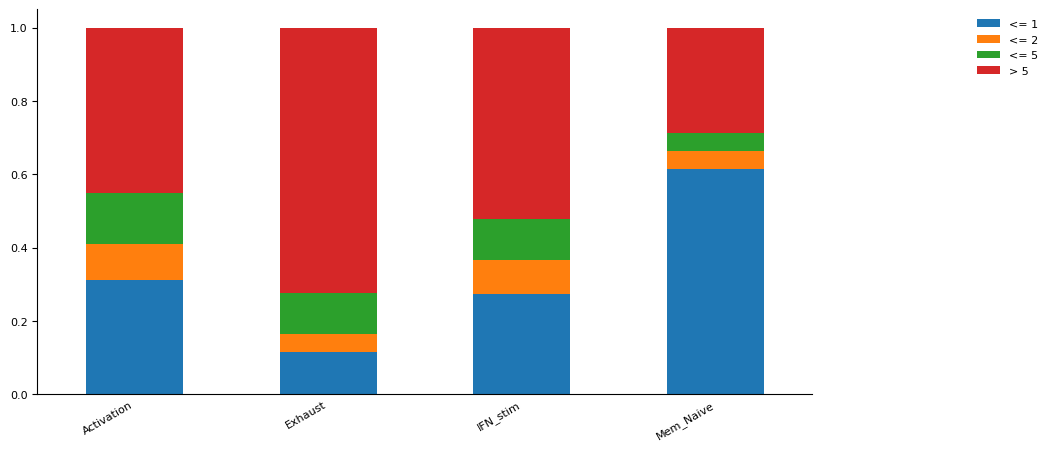

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby="state",  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

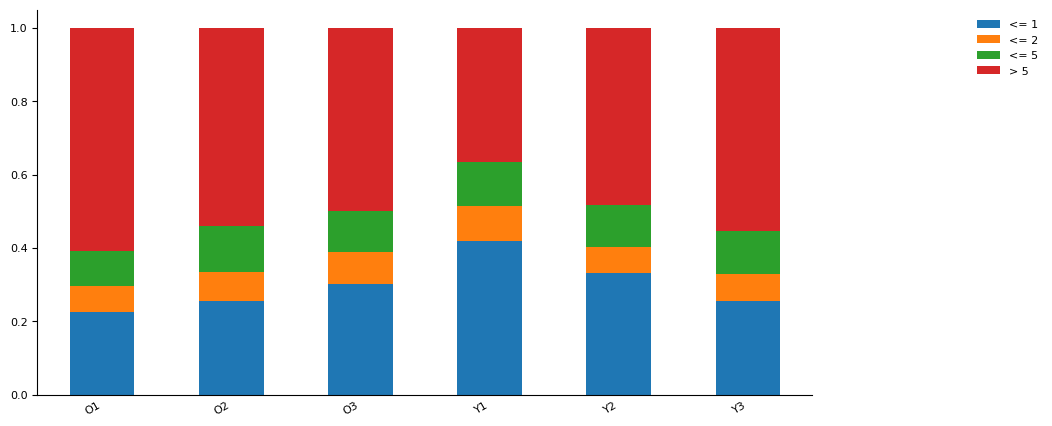

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'sample_id',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

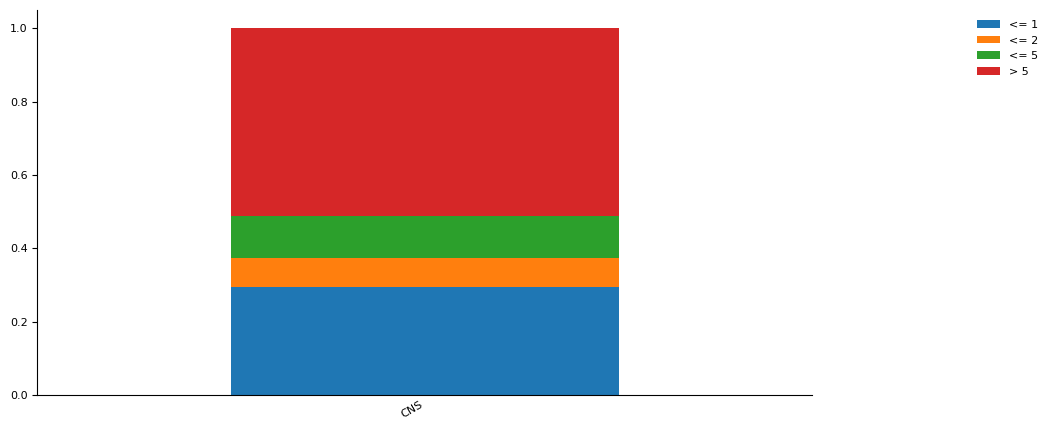

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
_ = ir.pl.clonal_expansion(
    mdata, 
    target_col="clone_id",
    groupby= 'tissue',  # Use the new combined column
    breakpoints=(1, 2, 5), 
    ax = ax
    #normalize=False
)

In [17]:
# mdata.write('yz_processed_allGenes_annotateByRef.h5mu')
mdata.write('yz_processed_allGenes_annotateByScore.h5mu')

In [18]:
aa

NameError: name 'aa' is not defined

# cluster and plot

In [ ]:
sc.pp.pca(mdata["gex"], svd_solver="arpack", n_comps=50)
sc.pp.neighbors(mdata["gex"], n_neighbors = 50)
sc.tl.umap(mdata["gex"], min_dist=0.5, spread=1.0)

In [ ]:
sc.pl.umap(mdata["gex"], color=['state', 'tissue', 'cell_type'], ncols=2,)

In [ ]:
# markers_in = []
# for i in ['Ccr6', 'Il22', 'Il17', 'Il17a'] + genes:
#     if i in mdata["gex"].var_names:
#         markers_in.append(i) 
# mu.pl.embedding(mdata["gex"], basis="umap", color= markers_in,  wspace = 0.1, ncols=2, vmin=0)